## Script for statistics of binary relevance prediction

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import utils
import os

In [4]:
#setting filepaths of the results

pi_results_filepath = "../prediction_results/PI_results/PI_"

nnrti_results_filepath = "../prediction_results/NNRTI_results/NNRTI_"

nrti_results_filepath = "../prediction_results/NRTI_results/NRTI_"

ini_results_filepath = "../prediction_results/INI_results/INI_"



#creating lists with filepaths for later visualisation
filepath_list = [pi_results_filepath, nnrti_results_filepath, nrti_results_filepath, ini_results_filepath]




#setting filepaths the datasets

pi_results_filepath_ml = "../prediction_results/PI_results/"

nnrti_results_filepath_ml = "../prediction_results/NNRTI_results/"

nrti_results_filepath_ml = "../prediction_results/NRTI_results/"

ini_results_filepath_ml = "../prediction_results/INI_results/"



#creating lists with filepaths for later visualisation
filepath_list_ml = [pi_results_filepath_ml, nnrti_results_filepath_ml, nrti_results_filepath_ml, ini_results_filepath_ml]



In [5]:
file = "Binary_Relevance_MOC_prediction.csv"

models = ["", "RandomForest_", "XGBoost_", "CatBoost_"]

sub_accs = {}



for path in filepath_list:
    acc_list = []
    for model in models:
        results = pd.read_csv(path + model + file)
        true_labels = results.filter(regex="True_*")
        pred_labels = results.filter(regex="Pred_*")

        sub_acc = utils.subset_acc(pred_labels, true_labels)

        acc_list.append(sub_acc)
    sub_accs.update({path.split("/")[-1].strip("_"):acc_list})


print(sub_accs)

df_sub_accs = pd.DataFrame(sub_accs)


#plt.bar(df_sub_accs)

{'PI': [0.6578171091445427, 0.6283185840707964, 0.640117994100295, 0.6519174041297935], 'NNRTI': [0.6896551724137931, 0.5517241379310345, 0.5517241379310345, 0.5689655172413793], 'NRTI': [0.5732368896925859, 0.5479204339963833, 0.5623869801084991, 0.5515370705244123], 'INI': [0.6274509803921569, 0.5490196078431373, 0.5686274509803921, 0.6274509803921569]}


Axes(0.125,0.53;0.352273x0.35)
0
Axes(0.547727,0.53;0.352273x0.35)
1
Axes(0.125,0.11;0.352273x0.35)
2
Axes(0.547727,0.11;0.352273x0.35)
3


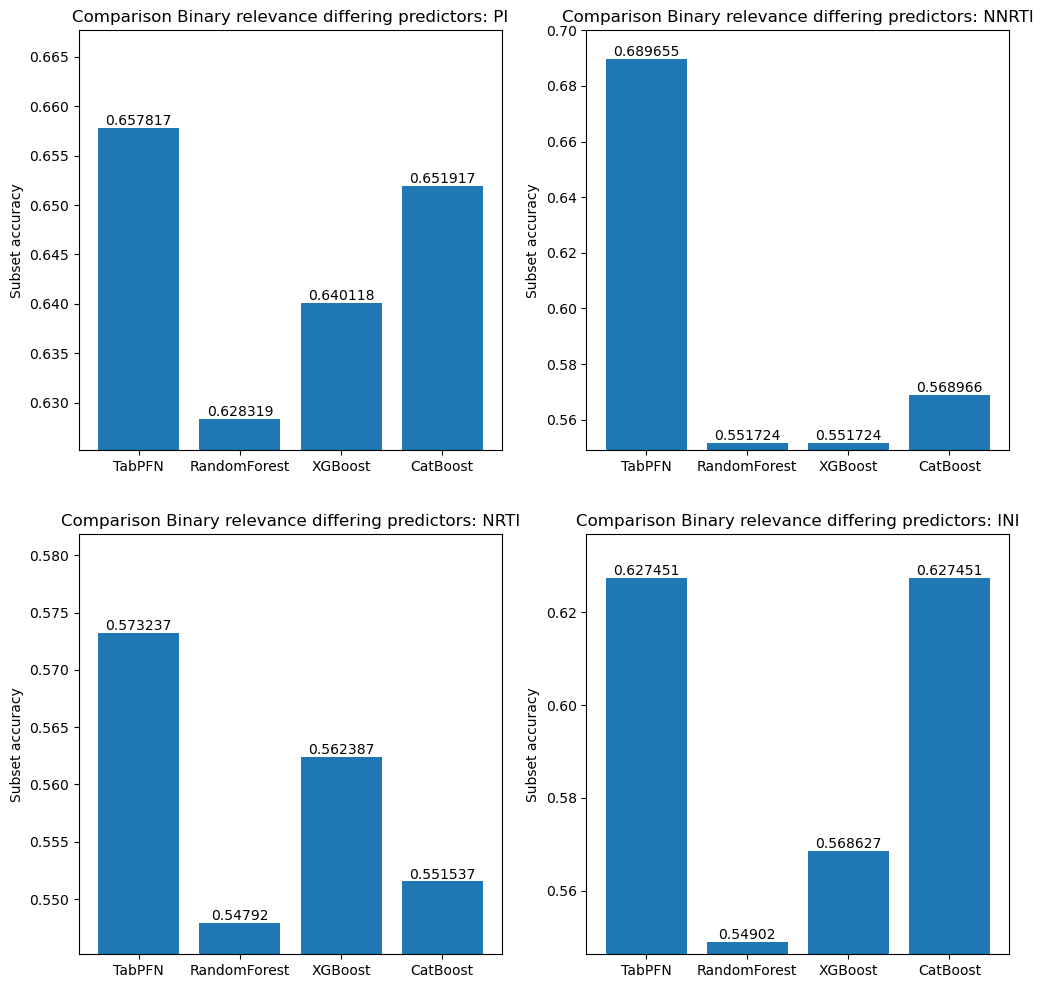

In [4]:
models_w_TabPFN = ["TabPFN", "RandomForest", "XGBoost", "CatBoost"]

fig, axs = plt.subplots(2, 2, figsize=(12, 12))

axs = axs.flatten()

for i, drug in enumerate(df_sub_accs.columns.values.tolist()):

    print(axs[i])
    print(i)

    p = axs[i].bar(models_w_TabPFN, df_sub_accs[drug])

    axs[i].bar_label(p, label_type="edge")

    #axs[i].set_xticks(x)
    #axs[i].set_xticklabels(target_ml["Drug"])
    axs[i].set_ylabel('Subset accuracy')
    axs[i].set_ylim(max(0, df_sub_accs[drug].min()* 0.995), min(1.0, df_sub_accs[drug].max()  * 1.015))
    axs[i].set_title('Comparison Binary relevance differing predictors: ' + drug)




plt.savefig("../figures/" + drug + "_Binary_relevance_model_comparison.png")


In [5]:
file = "Binary_Relevance_5_fold_MOC_prediction.csv"

models = ["", "RandomForest_", "XGBoost_", "CatBoost_"]

sub_accs_fold_mean = {}
sub_accs_fold_std = {}

for path in filepath_list:
    acc_list_mean = []
    acc_list_std = []

    for model in models:
        results = pd.read_csv(path + model + file)
        subs_accs_groups = results.groupby(by="kFolds").apply(lambda x: utils.subset_acc(x.filter(regex="Pred_*"), x.filter(regex="True_*")), include_groups=False)

        acc_list_mean.append(subs_accs_groups.mean())
        acc_list_std.append(subs_accs_groups.std())

    sub_accs_fold_mean.update({path.split("/")[-1].strip("_"):acc_list_mean})
    sub_accs_fold_std.update({path.split("/")[-1].strip("_"):acc_list_std})


#print(sub_accs)

#df_sub_accs_groups = pd.DataFrame(subs_accs_groups)


#plt.bar(df_sub_accs)

In [6]:
df_sub_accs_groups_mean = pd.DataFrame(sub_accs_fold_mean)
df_sub_accs_groups_std = pd.DataFrame(sub_accs_fold_std)

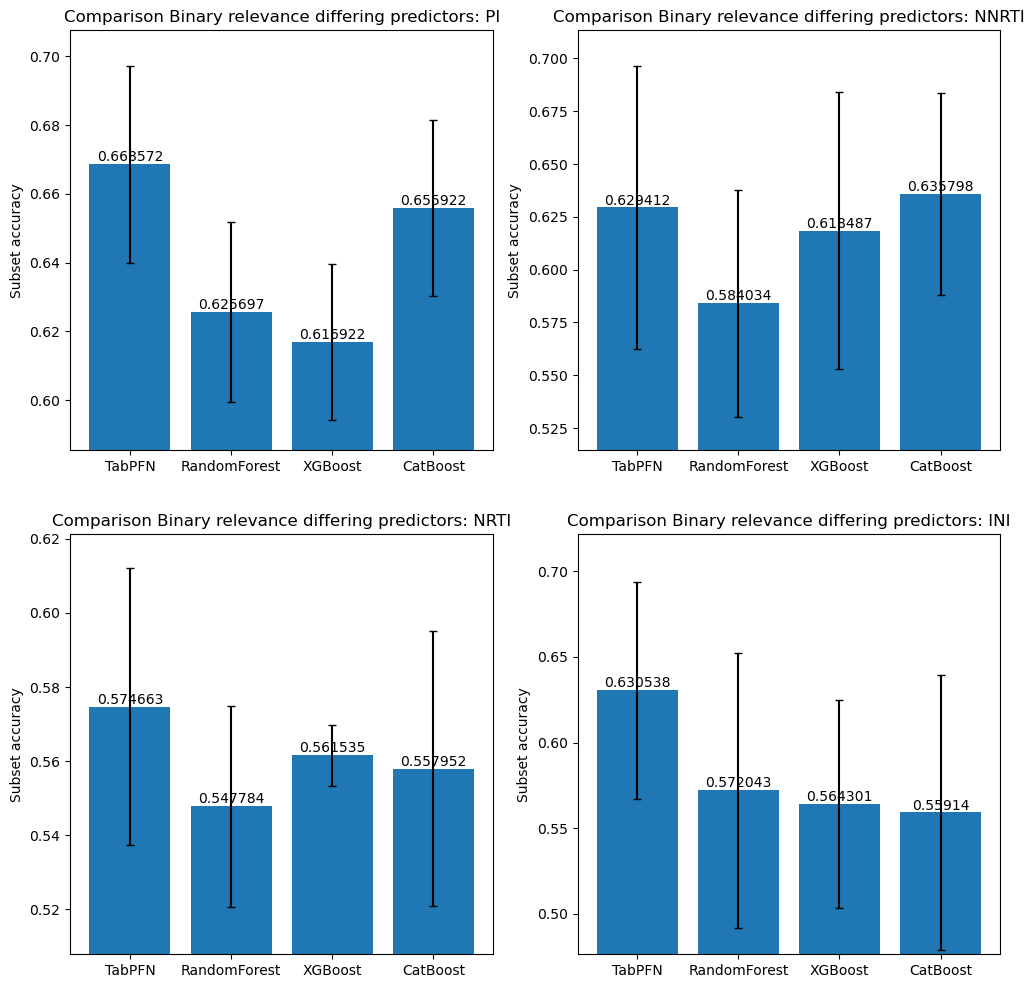

In [7]:
models_w_TabPFN = ["TabPFN", "RandomForest", "XGBoost", "CatBoost"]

fig, axs = plt.subplots(2, 2, figsize=(12, 12))

axs = axs.flatten()

for i, drug in enumerate(df_sub_accs_groups_mean.columns.values.tolist()):

    #print(axs[i])
    #print(i)

    p = axs[i].bar(models_w_TabPFN, df_sub_accs_groups_mean[drug])
    axs[i].errorbar(models_w_TabPFN, df_sub_accs_groups_mean[drug], yerr=df_sub_accs_groups_std[drug],capsize=3, fmt="none", ecolor="black")

    axs[i].bar_label(p, label_type="edge")

    #axs[i].set_xticks(x)
    #axs[i].set_xticklabels(target_ml["Drug"])
    axs[i].set_ylabel('Subset accuracy')
    axs[i].set_ylim(max(0, (df_sub_accs_groups_mean[drug].min() - df_sub_accs_groups_std[drug].max()) * 0.995), min(1.0 + df_sub_accs_groups_std[drug].max(), (df_sub_accs_groups_mean[drug].max() + df_sub_accs_groups_std[drug].max())  * 1.015))
    axs[i].set_title('Comparison Binary relevance differing predictors: ' + drug)


plt.savefig("../figures/" + drug + "_Binary_relevance_kfold_model_comparison.png")

    #plt.savefig("../figures/" + filepath_ml.split("/")[-1].split("_")[0] + "_Multilabel_Comparison.png")


In [8]:

#file = "_results/Multilabel_prediction.csv"
file = "_results/Binary_complete_labels_Multilabel_prediction.csv"


#models = ["", "RandomForest_", "XGBoost_", "CatBoost_"]

sub_accs_old = []

targets = ["PI", "NNRTI", "NRTI", "INI"]

for path in filepath_list_ml:

    df_old_ml_pred = pd.DataFrame()

    drugs = [file_name.strip("_results") for file_name in os.listdir(path) if "_results" in file_name]

    #acc_list = []


    for drug in drugs:
        results = pd.read_csv(path + drug + file)

        df_old_ml_pred["True_" + drug] = results["True"]

        #print(drug)

        df_old_ml_pred["Pred_" + drug] = [1.0 if proba >= 0.5 else 0.0 for proba in results["1"]]

    #print(df_old_ml_pred)

    true_labels = df_old_ml_pred.filter(regex="True_*")
    pred_labels = df_old_ml_pred.filter(regex="Pred_*")

    #print(true_labels)
    #print(pred_labels)

    sub_accs_old.append(utils.subset_acc(pred_labels, true_labels))

sub_accs_new = df_sub_accs.loc[0,:]

print(sub_accs_old)



[0.6519174041297935, 0.7413793103448276, 0.6003616636528029, 0.7843137254901961]


[0.6578171091445427, 0.6519174041297935]
[0.6896551724137931, 0.7413793103448276]
[0.5732368896925859, 0.6003616636528029]
[0.6274509803921569, 0.7843137254901961]


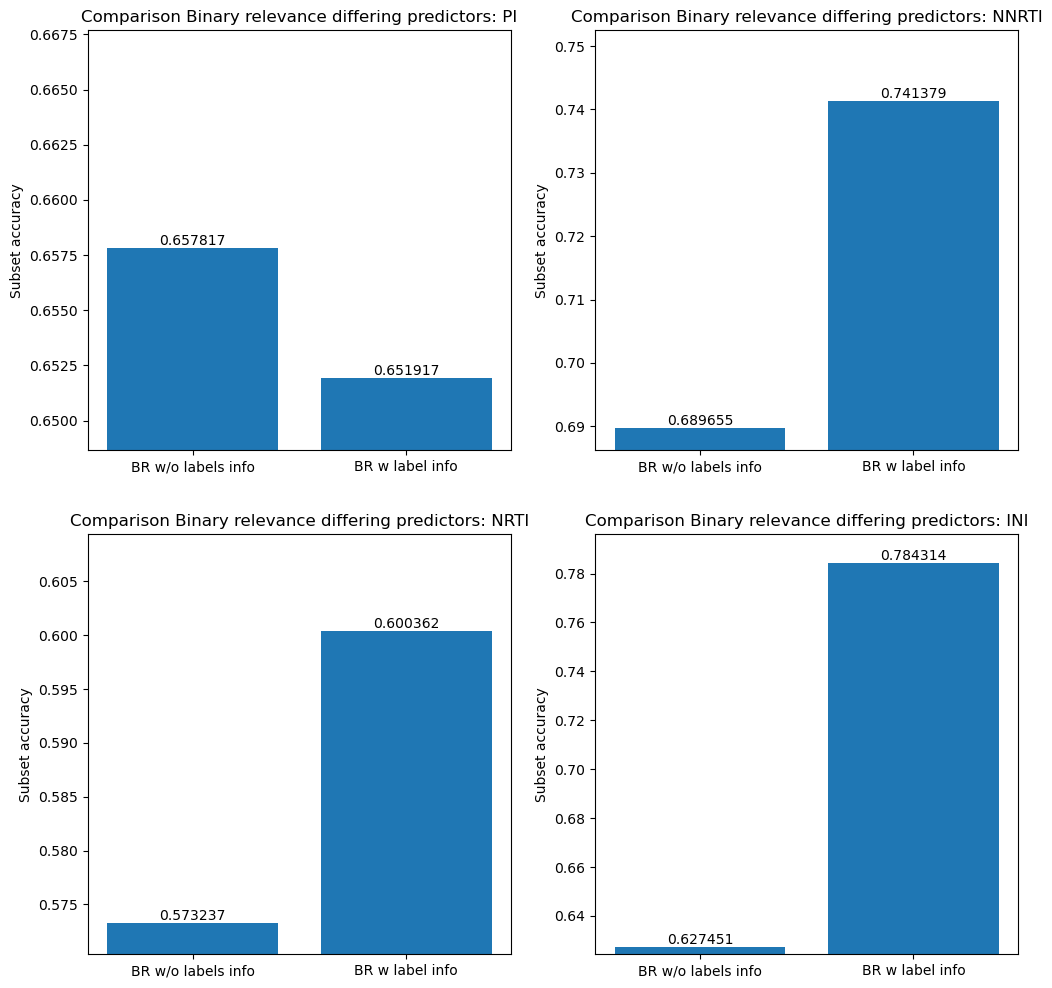

In [9]:
models_ml = ["BR w/o labels info", "BR w label info"]


targets = ["PI", "NNRTI", "NRTI", "INI"]

fig, axs = plt.subplots(2, 2, figsize=(12, 12))

axs = axs.flatten()

for i, target in enumerate(targets):

    y = [sub_accs_new[target], sub_accs_old[i]]

    print(y)

    p = axs[i].bar(models_ml, y)

    axs[i].bar_label(p, label_type="edge")

    #axs[i].set_xticks(x)
    #axs[i].set_xticklabels(target_ml["Drug"])
    axs[i].set_ylabel('Subset accuracy')
    axs[i].set_ylim(max(0, min(y) * 0.995), min(1.0, max(y)  * 1.015))
    axs[i].set_title('Comparison Binary relevance differing predictors: ' + target)


plt.savefig("../figures/" + drug + "_Binary_relevance_label_info_comparison.png")

    #plt.savefig("../figures/" + filepath_ml.split("/")[-1].split("_")[0] + "_Multilabel_Comparison.png")
